##  Example 1

### Cell Composition Landscape of CRC

C:\WINDOWSl\Temp\ipykernel_23816\1561962855.py:22: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(data=df, x='subtype', y='percentage', palette='viridis')


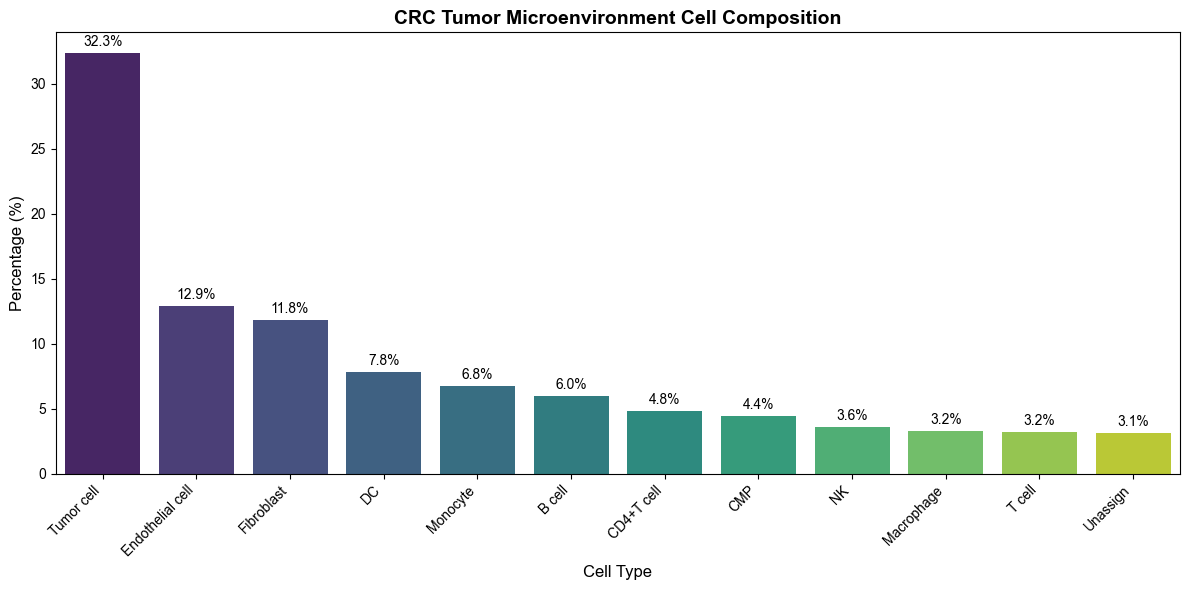

In [22]:
from curl_cffi import requests
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Set Arial font
plt.rcParams['font.family'] = 'Arial'

Tumor = 'CRC'
# Fetch data
API = f"https://bio-bigdata.hrbmu.edu.cn/scolnc/searchCancerProp?cancer={Tumor}"
response = requests.get(API, impersonate="chrome")
data = response.json()

# Prepare DataFrame
df = pd.DataFrame(data['data']['rows'])
df['percentage'] = df['percentage'].astype(float) * 100
df = df.sort_values('percentage', ascending=False)

# Plot
plt.figure(figsize=(12, 6))
ax = sns.barplot(data=df, x='subtype', y='percentage', palette='viridis')
plt.title(f'{Tumor} Tumor Microenvironment Cell Composition', fontsize=14, fontweight='bold')
plt.xlabel('Cell Type', fontsize=12)
plt.ylabel('Percentage (%)', fontsize=12)
plt.xticks(rotation=45, ha='right')

# Add value labels
for p in ax.patches:
    ax.annotate(f'{p.get_height():.1f}%', 
                (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='center', xytext=(0, 8), textcoords='offset points')

plt.tight_layout()
plt.show()

### Co-regulated lncRNA Interactome in CRC

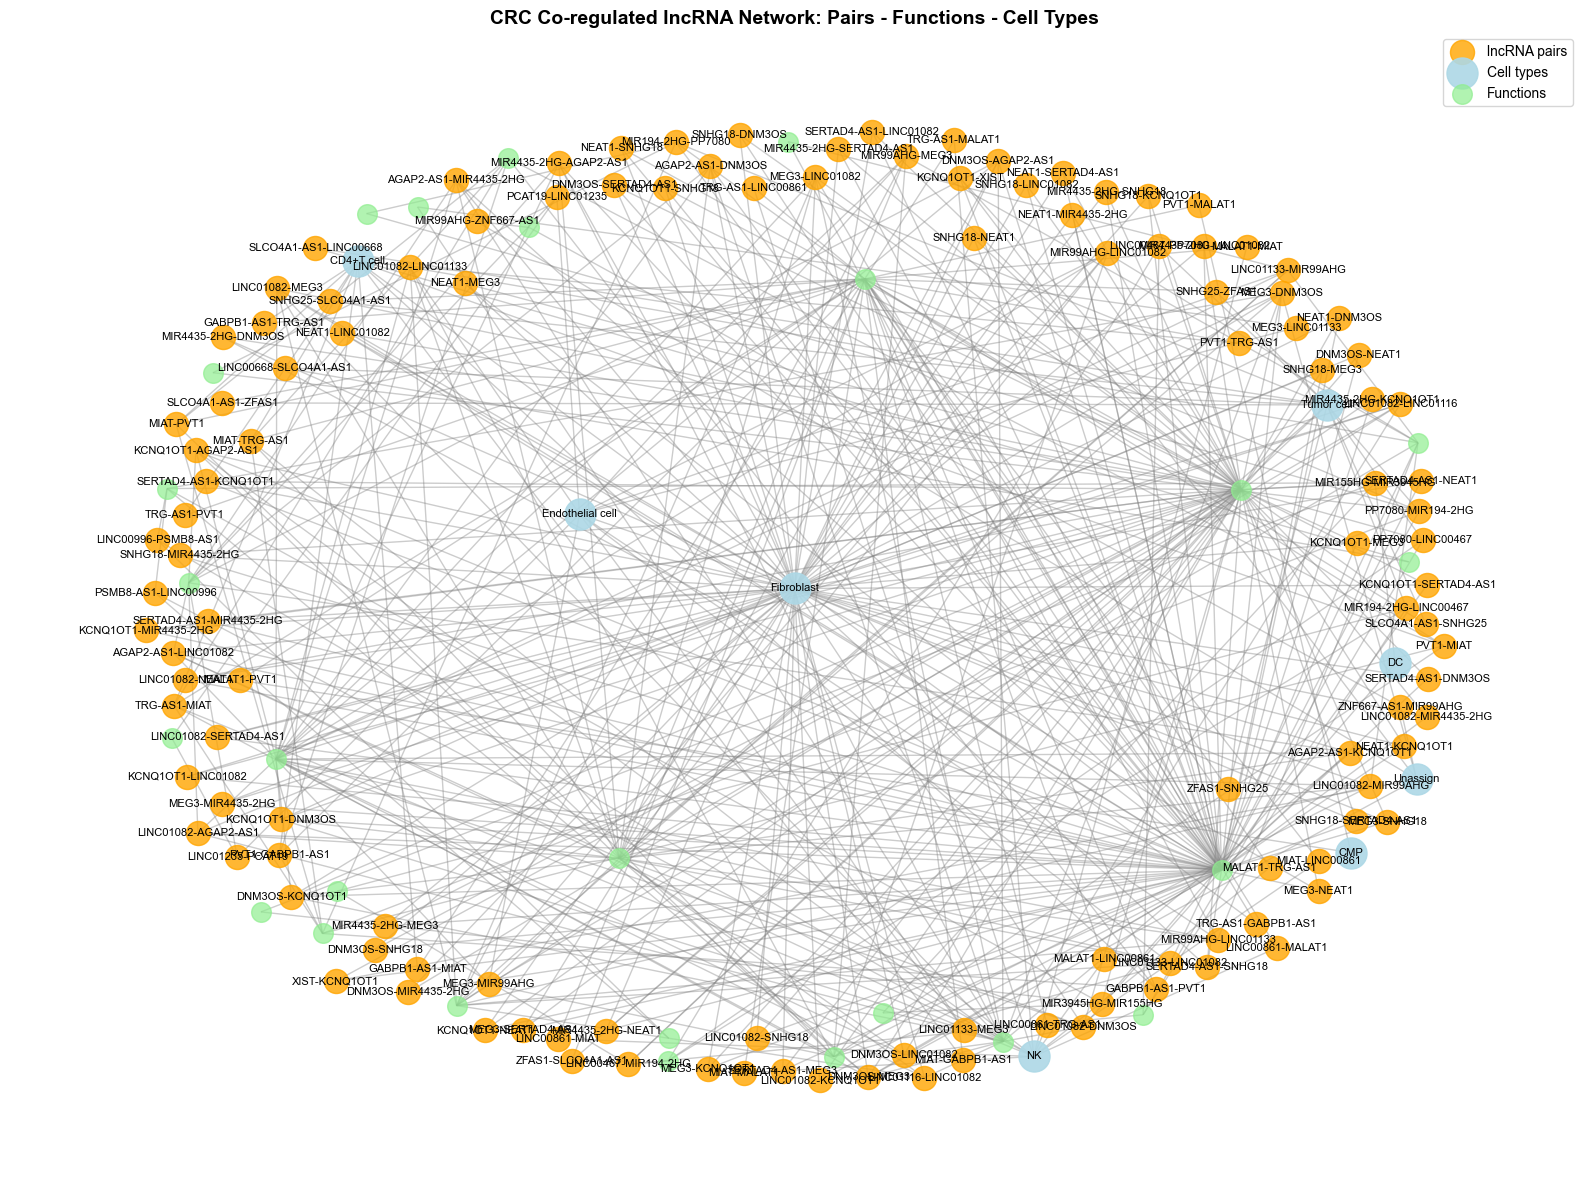

Total nodes: 158
  lncRNA pairs: 124
  Cell types: 8
  Functions: 26
Total edges: 452


In [29]:
from curl_cffi import requests
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt
from collections import defaultdict

# Set Arial font
plt.rcParams['font.family'] = 'Arial'

# Configuration
Tumor = 'CRC'
API = f"https://bio-bigdata.hrbmu.edu.cn/scolnc/searchAddCo?cancer={Tumor}"

# Fetch data
response = requests.get(API, impersonate="chrome")
data = response.json()
df = pd.DataFrame(data['data'])

# Build network: lncRNA pair -> functions -> cell types
G = nx.Graph()

# Add nodes and edges
for _, row in df.iterrows():
    lnc_pair = f"{row['lncRna1']}-{row['lncRna2']}"
    cell = row['cellType']
    functions = row['functional'].split(';') if pd.notna(row['functional']) else []
    
    # Add lncRNA pair node
    G.add_node(lnc_pair, type='lncRNA', size=200)
    
    # Add cell type node
    G.add_node(cell, type='cell', size=100)
    G.add_edge(lnc_pair, cell, weight=row['intensityScore'])
    
    # Add function nodes and edges (limit to first 5 for readability)
    for func in functions[:5]:  # Limit to avoid overcrowding
        func_short = func.split('_')[-1] if '_' in func else func  # Shorten function name
        G.add_node(func_short, type='function', size=50)
        G.add_edge(lnc_pair, func_short, weight=1)

# Separate nodes by type for plotting
lnc_nodes = [n for n, d in G.nodes(data=True) if d.get('type') == 'lncRNA']
cell_nodes = [n for n, d in G.nodes(data=True) if d.get('type') == 'cell']
func_nodes = [n for n, d in G.nodes(data=True) if d.get('type') == 'function']

# Plot
plt.figure(figsize=(16, 12))
pos = nx.spring_layout(G, k=3, seed=42)

# Draw nodes with different colors
nx.draw_networkx_nodes(G, pos, nodelist=lnc_nodes, node_color='orange', 
                       node_size=300, label='lncRNA pairs', alpha=0.8)
nx.draw_networkx_nodes(G, pos, nodelist=cell_nodes, node_color='lightblue', 
                       node_size=500, label='Cell types', alpha=0.9)
nx.draw_networkx_nodes(G, pos, nodelist=func_nodes, node_color='lightgreen', 
                       node_size=200, label='Functions', alpha=0.7)

# Draw edges
nx.draw_networkx_edges(G, pos, alpha=0.4, edge_color='gray')

# Draw labels (only for cell types and lncRNA pairs for clarity)
labels = {n: n for n in cell_nodes}
labels.update({n: n for n in lnc_nodes})
nx.draw_networkx_labels(G, pos, labels=labels, font_size=8, font_family='Arial')

plt.title(f'{Tumor} Co-regulated lncRNA Network: Pairs - Functions - Cell Types', 
          fontsize=14, fontweight='bold')
plt.legend()
plt.axis('off')
plt.tight_layout()
plt.show()

# Print statistics
print(f"Total nodes: {G.number_of_nodes()}")
print(f"  lncRNA pairs: {len(lnc_nodes)}")
print(f"  Cell types: {len(cell_nodes)}")
print(f"  Functions: {len(func_nodes)}")
print(f"Total edges: {G.number_of_edges()}")

### Functional Enrichment Atlas of CRC

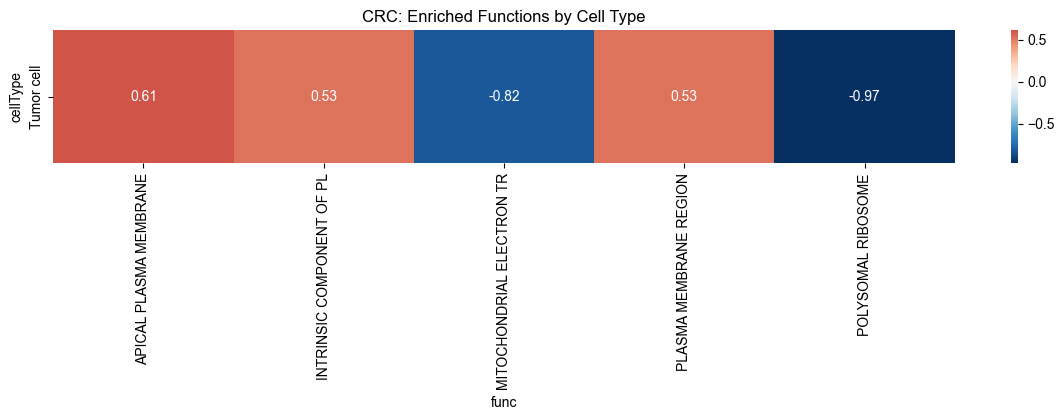

In [32]:
from curl_cffi import requests
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

plt.rcParams['font.family'] = 'Arial'

Tumor = 'CRC'
API = f"https://bio-bigdata.hrbmu.edu.cn/scolnc/searchFunctionByTumor?name={Tumor}"

response = requests.get(API, impersonate="chrome")
data = response.json()
df = pd.DataFrame(data['data']['rows'])

# Filter and prepare
df_sig = df[df['padjust'].astype(float) < 0.05].copy()
df_sig['enrichmentScore'] = df_sig['enrichmentScore'].astype(float)

# Get top 5 per cell type
df_top = df_sig.sort_values(['cellType', 'enrichmentScore'], ascending=[True, False])
df_top = df_top.groupby('cellType').head(5)

# Simplify function names
df_top['func'] = df_top['id'].str.replace('GOCC_|GOBP_|GOMF_', '', regex=True)
df_top['func'] = df_top['func'].str.replace('_', ' ', regex=False).str[:25]

# Create heatmap data
pivot = df_top.pivot_table(index='cellType', columns='func', values='enrichmentScore')
pivot = pivot.fillna(0)

# Only proceed if data exists
if not pivot.empty:
    plt.figure(figsize=(12, len(pivot.index) * 0.3 + 4))
    sns.heatmap(pivot, annot=True, fmt='.2f', cmap='RdBu_r', center=0)
    plt.title(f'{Tumor}: Enriched Functions by Cell Type')
    plt.tight_layout()
    plt.show()
else:
    print("No significant enrichment found")

## Example2

### Co-regulated lncRNA

In [ ]:
# Co-regulated lncRNA Table
import pandas as pd
from curl_cffi import requests

Gene = "MEG3"
API_co = f"https://bio-bigdata.hrbmu.edu.cn/scolnc/searchAddCo?name={Gene}"
resp_co = requests.get(API_co, impersonate="chrome")
df_co = pd.DataFrame(resp_co.json()['data'])

print("\nCo-regulated lncRNA:")
print(df_co[['geneId1', 'lncRna1', 'geneId2', 'lncRna2', 'jaccordIndex',
       'intensityScore', 'cellType', 'tumorType', 'functionalType',
       'functional']].head(10).to_string(index=False))


Co-regulated lncRNA:
        geneId1 lncRna1         geneId2     lncRna2      jaccordIndex    intensityScore         cellType tumorType functionalType                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                             functional
ENSG00000

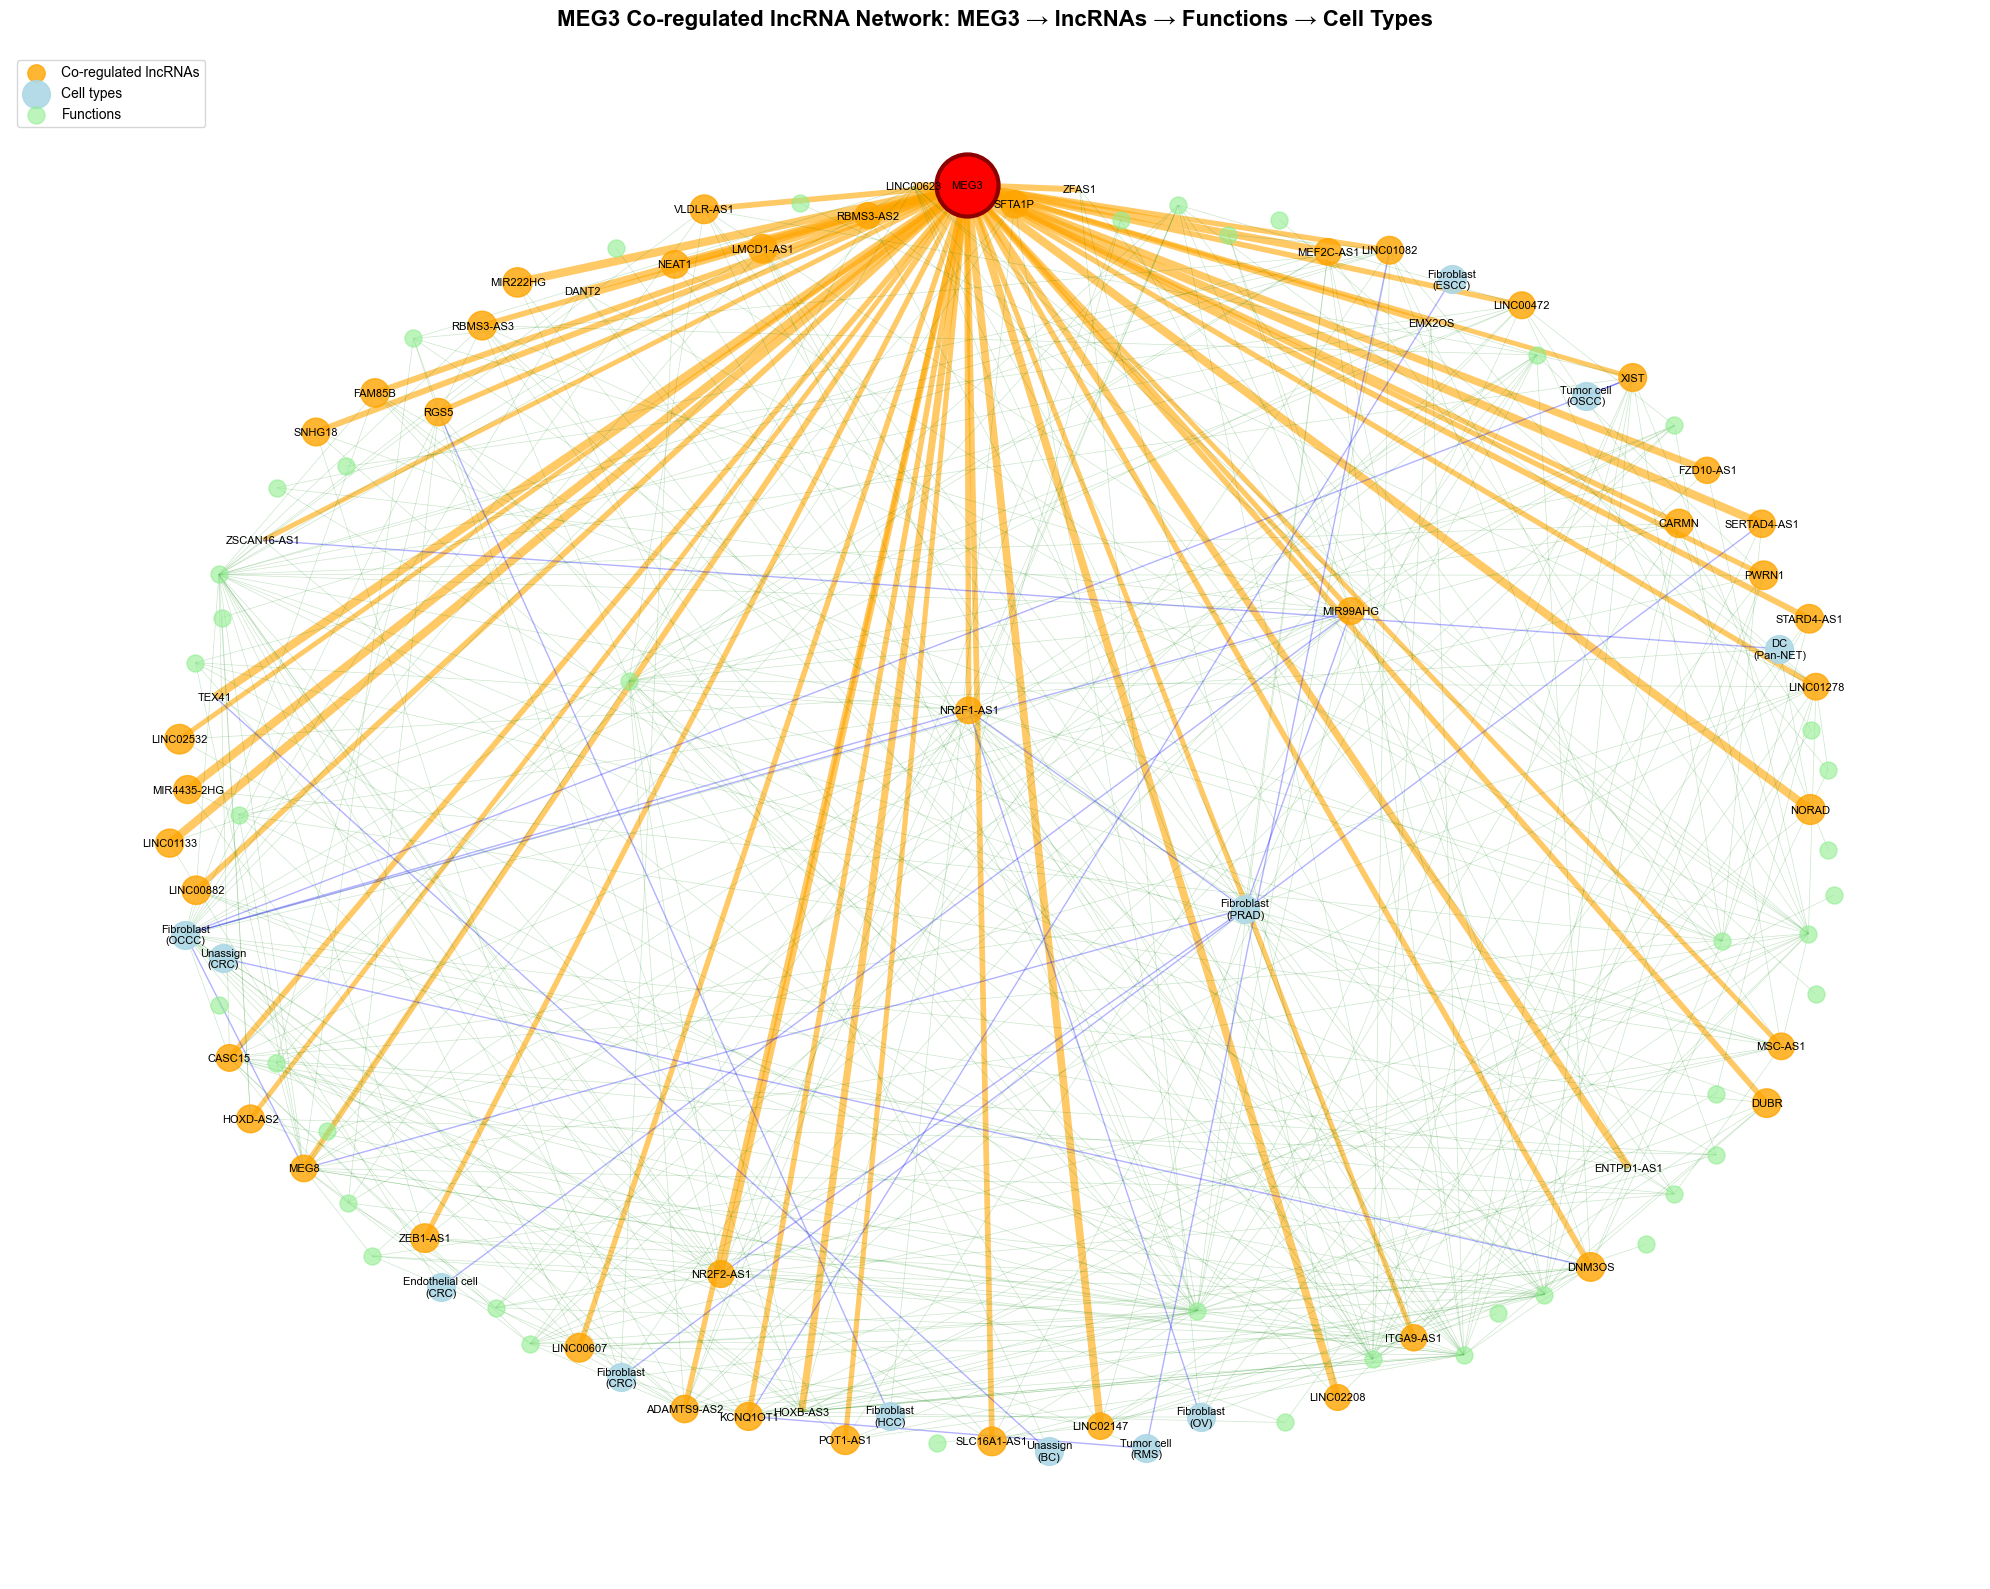

Network Statistics:
  Total nodes: 105
  MEG3 center: 1
  Co-regulated lncRNAs: 51
  Cell types: 12
  Functions: 41
Total edges: 440


In [ ]:
from curl_cffi import requests
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt

# Set Arial font
plt.rcParams['font.family'] = 'Arial'

# Configuration
Gene = "MEG3"
API_co = f"https://bio-bigdata.hrbmu.edu.cn/scolnc/searchAddCo?name={Gene}"

# Fetch data
response = requests.get(API_co, impersonate="chrome")
data = response.json()
df = pd.DataFrame(data['data'])

# Build network: MEG3 -> co-regulated lncRNAs -> functions -> cell types
G = nx.Graph()

# Add MEG3 as central node
G.add_node('MEG3', type='center', size=800)

for _, row in df.iterrows():
    lnc = row['lncRna2']
    cell = row['cellType']
    tumor = row['tumorType']
    functions = row['functional'].split(';') if pd.notna(row['functional']) else []
    jaccard = float(row['jaccordIndex'])
    intensity = float(row['intensityScore'])
    
    # Add lncRNA node
    G.add_node(lnc, type='lncRNA', size=300, intensity=intensity, tumor=tumor, cell=cell)
    G.add_edge('MEG3', lnc, weight=jaccard, intensity=intensity)
    
    # Add cell type node
    cell_label = f"{cell}\n({tumor})"
    G.add_node(cell_label, type='cell', size=400)
    G.add_edge(lnc, cell_label, weight=intensity)
    
    # Add function nodes (limit to top 5 for readability)
    for func in functions[:5]:
        # Extract GO term name
        func_short = func.split('_')[-1] if '_' in func else func
        func_short = func_short.replace('_', ' ')
        if len(func_short) > 25:
            func_short = func_short[:22] + '...'
        
        G.add_node(func_short, type='function', size=150)
        G.add_edge(lnc, func_short, weight=1)

# Separate nodes by type for plotting
center_nodes = [n for n, d in G.nodes(data=True) if d.get('type') == 'center']
lnc_nodes = [n for n, d in G.nodes(data=True) if d.get('type') == 'lncRNA']
cell_nodes = [n for n, d in G.nodes(data=True) if d.get('type') == 'cell']
func_nodes = [n for n, d in G.nodes(data=True) if d.get('type') == 'function']

# Plot
plt.figure(figsize=(20, 16))
pos = nx.spring_layout(G, k=5, seed=42, iterations=100)

# Draw edges with different colors based on connection type
# Edges: MEG3-lncRNA (weighted by Jaccard)
for edge in G.edges(data=True):
    if edge[0] == 'MEG3' or edge[1] == 'MEG3':
        width = 1 + 5 * edge[2]['weight']
        nx.draw_networkx_edges(G, pos, edgelist=[(edge[0], edge[1])], 
                               width=width, alpha=0.6, edge_color='orange')
    elif G.nodes[edge[0]].get('type') == 'lncRNA' and G.nodes[edge[1]].get('type') == 'cell':
        nx.draw_networkx_edges(G, pos, edgelist=[(edge[0], edge[1])], 
                               width=1, alpha=0.3, edge_color='blue')
    else:
        nx.draw_networkx_edges(G, pos, edgelist=[(edge[0], edge[1])], 
                               width=0.5, alpha=0.2, edge_color='green')

# Draw nodes
# MEG3 center
nx.draw_networkx_nodes(G, pos, nodelist=center_nodes, node_color='red', 
                       node_size=2000, alpha=1.0, edgecolors='darkred', linewidths=3)

# lncRNA nodes
lnc_sizes = [G.nodes[n].get('size', 300) * (0.5 + 0.5 * G.nodes[n].get('intensity', 0.5)) 
             for n in lnc_nodes]
nx.draw_networkx_nodes(G, pos, nodelist=lnc_nodes, node_color='orange', 
                       node_size=lnc_sizes, alpha=0.8, label='Co-regulated lncRNAs')

# Cell type nodes
nx.draw_networkx_nodes(G, pos, nodelist=cell_nodes, node_color='lightblue', 
                       node_size=400, alpha=0.9, label='Cell types')

# Function nodes
nx.draw_networkx_nodes(G, pos, nodelist=func_nodes, node_color='lightgreen', 
                       node_size=150, alpha=0.6, label='Functions')

# Draw labels (only for center, lncRNA, and cell types for clarity)
labels = {n: n for n in center_nodes}
labels.update({n: n for n in lnc_nodes})
labels.update({n: n for n in cell_nodes})
nx.draw_networkx_labels(G, pos, labels=labels, font_size=8, font_family='Arial')

plt.title('MEG3 Co-regulated lncRNA Network: MEG3 → lncRNAs → Functions → Cell Types', 
          fontsize=16, fontweight='bold', pad=20)
plt.legend(loc='upper left', fontsize=10)
plt.axis('off')
plt.tight_layout()
plt.show()

# Print statistics
print(f"Network Statistics:")
print(f"  Total nodes: {G.number_of_nodes()}")
print(f"  MEG3 center: 1")
print(f"  Co-regulated lncRNAs: {len(lnc_nodes)}")
print(f"  Cell types: {len(cell_nodes)}")
print(f"  Functions: {len(func_nodes)}")
print(f"Total edges: {G.number_of_edges()}")

### Cell type-specific lncRNA 

In [ ]:
# Cell type-specific lncRNA table
Gene = "MEG3"
API_sp = f"https://bio-bigdata.hrbmu.edu.cn/scolnc/searchAddSp?name={Gene}"
resp_sp = requests.get(API_sp, impersonate="chrome")
df_sp = pd.DataFrame(resp_sp.json()['data'])

print("\nCell type-specific lncRNA:")
print(df_sp[['geneId', 'lncRNA', 'tumorType', 'cellType', 'avgLog2FC', 'pct1',
       'pct2', 'function', 'funcState', 'funcIndex', 'lncColncState',
       'lncColncIndex', 'lncfunc', 'pval', 'pvalAdj']].head(10).to_string(index=False))


Cell type-specific lncRNA:
         geneId lncRNA tumorType         cellType         avgLog2FC              pct1                pct2                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                   

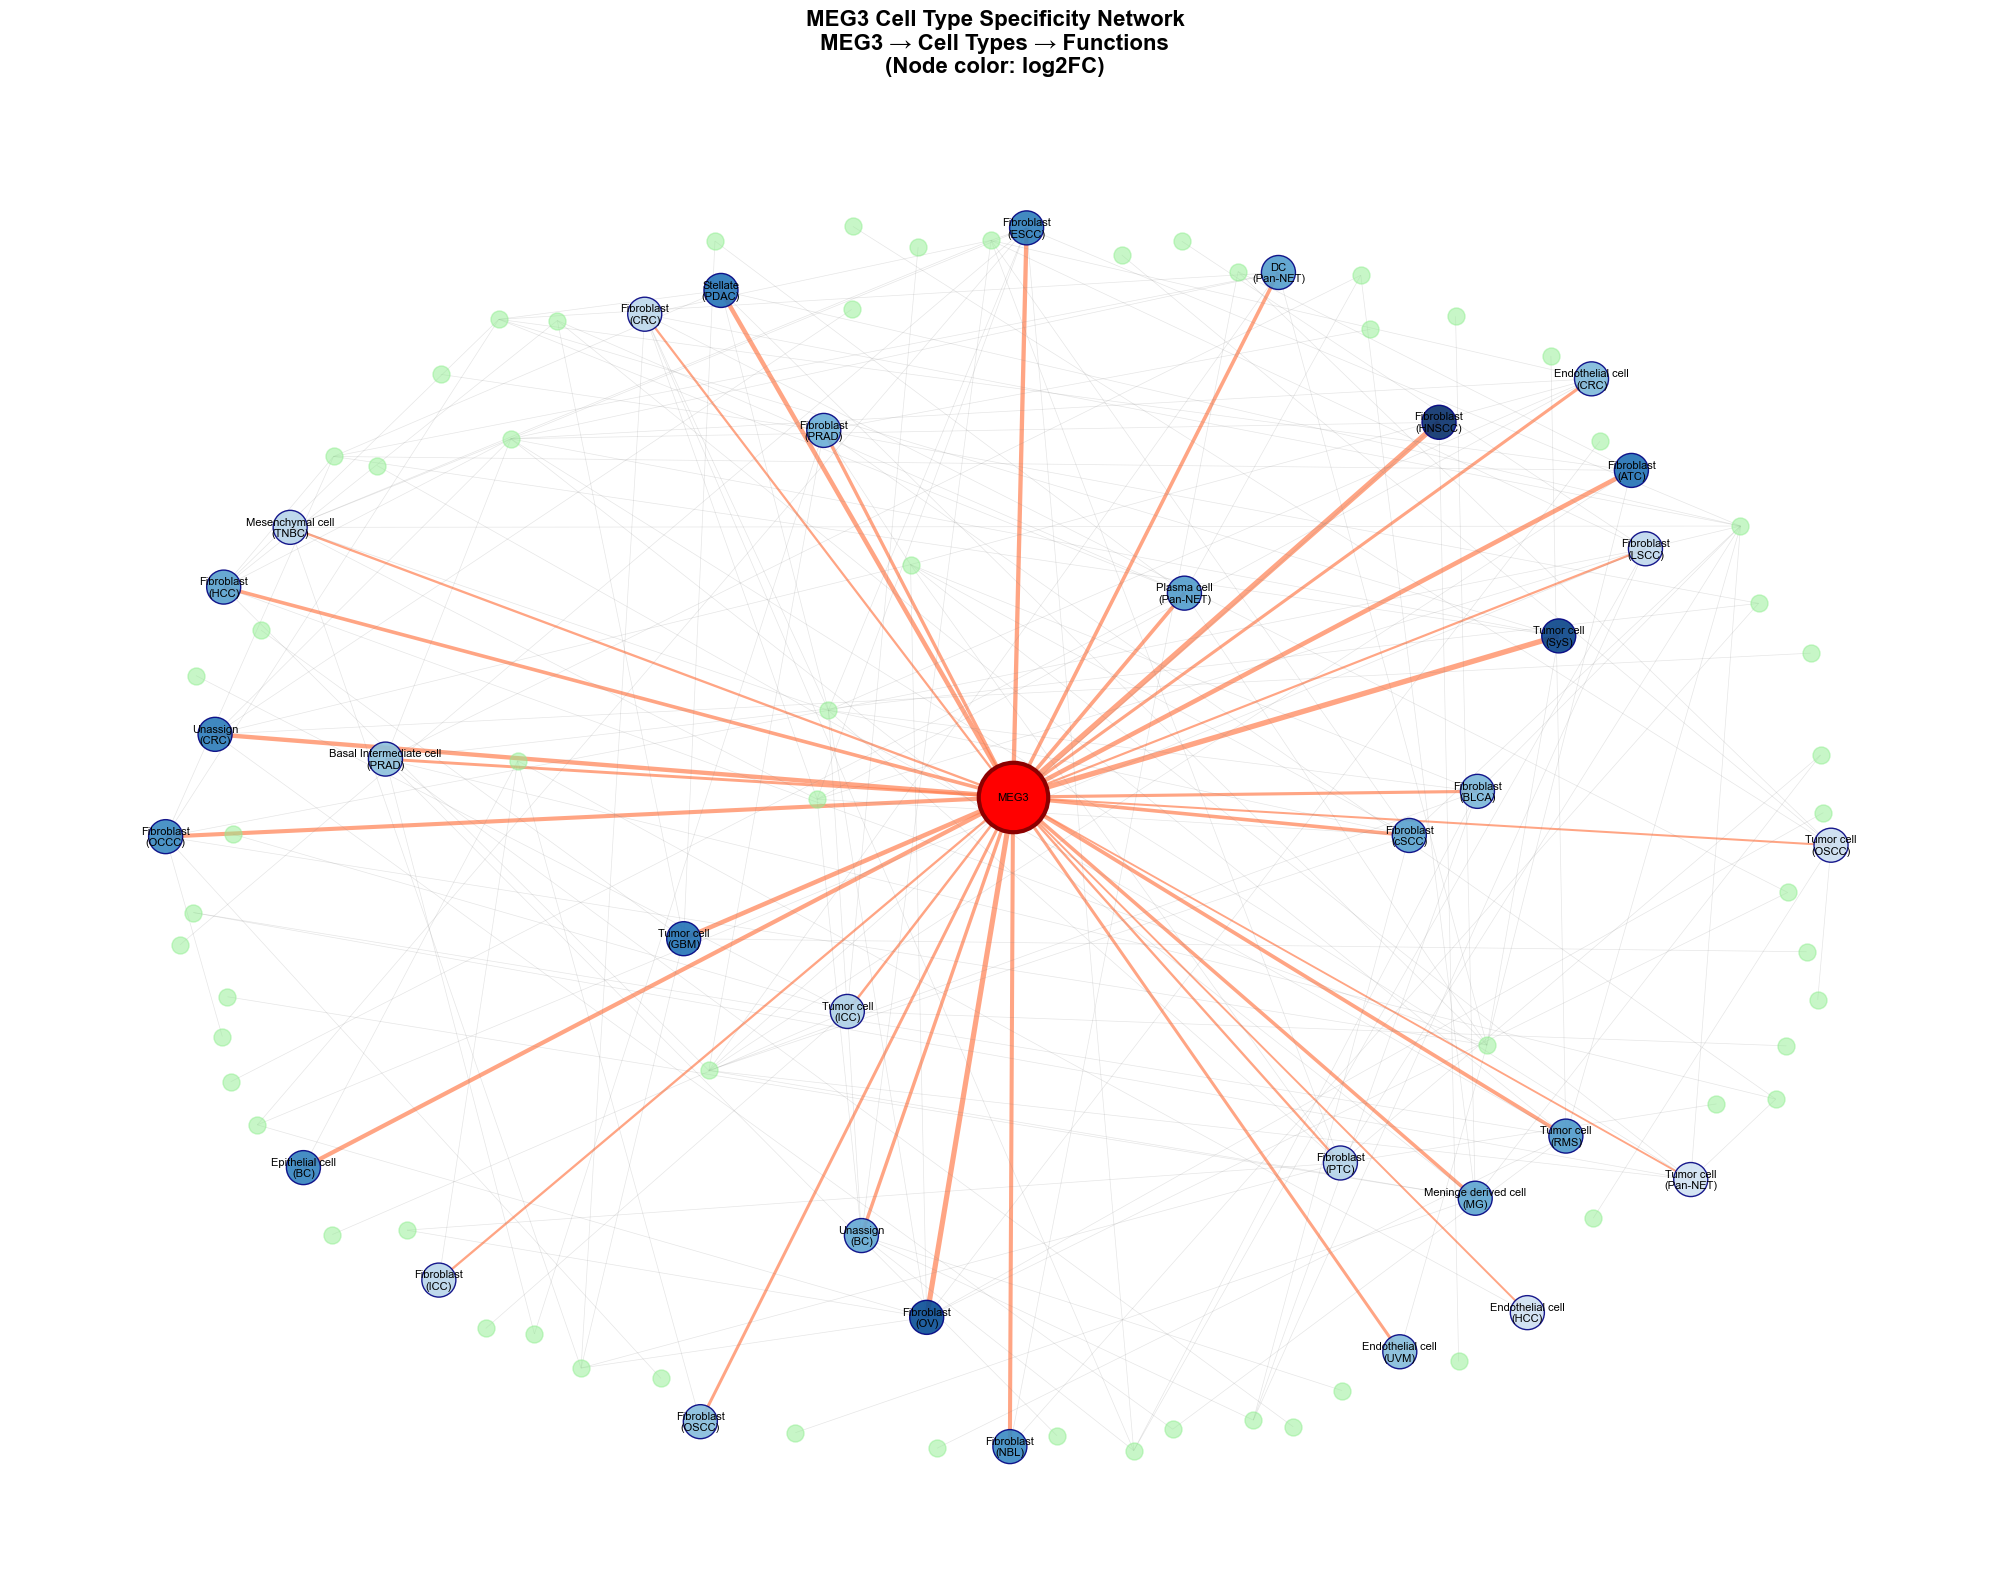

Network Statistics:
  Total nodes: 95
  MEG3 center: 1
  Cell types: 33
  Functions: 61
Total edges: 204

Cell types with log2FC:
  Fibroblast
(HNSCC): log2FC=3.127, p=0.00e+00
  Tumor cell
(SyS): log2FC=2.866, p=0.00e+00
  Fibroblast
(OV): log2FC=2.732, p=0.00e+00
  Fibroblast
(ATC): log2FC=2.259, p=0.00e+00
  Tumor cell
(GBM): log2FC=2.238, p=9.38e-69
  Stellate
(PDAC): log2FC=2.201, p=0.00e+00
  Unassign
(CRC): log2FC=2.122, p=2.86e-229
  Fibroblast
(ESCC): log2FC=2.093, p=0.00e+00
  Epithelial cell
(BC): log2FC=2.024, p=1.95e-241
  Fibroblast
(OCCC): log2FC=1.943, p=0.00e+00
  Fibroblast
(NBL): log2FC=1.912, p=1.26e-56
  Tumor cell
(RMS): log2FC=1.700, p=6.17e-171
  Plasma cell
(Pan-NET): log2FC=1.651, p=1.21e-129
  DC
(Pan-NET): log2FC=1.616, p=0.00e+00
  Fibroblast
(HCC): log2FC=1.593, p=0.00e+00
  Fibroblast
(cSCC): log2FC=1.575, p=0.00e+00
  Meninge derived cell
(MG): log2FC=1.540, p=0.00e+00
  Unassign
(BC): log2FC=1.467, p=3.17e-28
  Fibroblast
(PRAD): log2FC=1.389, p=2.69e-1

In [ ]:
from curl_cffi import requests
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt
import numpy as np

# Set Arial font
plt.rcParams['font.family'] = 'Arial'

# Get data
Gene = "MEG3"
API_sp = f"https://bio-bigdata.hrbmu.edu.cn/scolnc/searchAddSp?name={Gene}"
resp_sp = requests.get(API_sp, impersonate="chrome")
df_sp = pd.DataFrame(resp_sp.json()['data'])

# Build network: MEG3 -> Cell types -> Functions
G = nx.Graph()

# Add MEG3 as central node
G.add_node('MEG3', type='center', size=1000)

for _, row in df_sp.iterrows():
    tumor = row['tumorType']
    cell = row['cellType']
    log2fc = float(row['avgLog2FC'])
    pval = float(row['pval'])
    functions = row['function'].split(';') if pd.notna(row['function']) else []
    
    # Create cell type label
    cell_label = f"{cell}\n({tumor})"
    
    # Add cell type node
    G.add_node(cell_label, type='cell', size=500, log2fc=log2fc, pval=pval)
    G.add_edge('MEG3', cell_label, weight=abs(log2fc), pval=pval)
    
    # Add function nodes (limit to top 8 for readability)
    func_list = []
    for func in functions[:8]:
        # Extract short name
        if func.startswith('GO'):
            func_short = func.split('_')[-1] if '_' in func else func
        elif func.startswith('KEGG'):
            func_short = func.split('_')[-1] if '_' in func else func
        else:
            func_short = func
        
        func_short = func_short.replace('_', ' ')
        if len(func_short) > 20:
            func_short = func_short[:18] + '..'
        
        if func_short not in func_list:
            func_list.append(func_short)
            G.add_node(func_short, type='function', size=150)
            G.add_edge(cell_label, func_short, weight=1)

# Separate nodes by type
center_nodes = [n for n, d in G.nodes(data=True) if d.get('type') == 'center']
cell_nodes = [n for n, d in G.nodes(data=True) if d.get('type') == 'cell']
func_nodes = [n for n, d in G.nodes(data=True) if d.get('type') == 'function']

# Plot
fig, ax = plt.subplots(figsize=(20, 16))
pos = nx.spring_layout(G, k=3, seed=42, iterations=100)

# Draw edges with different colors
# MEG3 -> Cell types (weighted by log2FC)
for edge in G.edges(data=True):
    if edge[0] == 'MEG3' or edge[1] == 'MEG3':
        width = 1 + 3 * min(edge[2]['weight'], 3) / 3
        nx.draw_networkx_edges(G, pos, edgelist=[(edge[0], edge[1])], 
                               width=width, alpha=0.7, edge_color='coral')
    else:
        nx.draw_networkx_edges(G, pos, edgelist=[(edge[0], edge[1])], 
                               width=0.5, alpha=0.2, edge_color='gray')

# Draw nodes
# MEG3 center
nx.draw_networkx_nodes(G, pos, nodelist=center_nodes, node_color='red', 
                       node_size=2500, alpha=1.0, edgecolors='darkred', linewidths=3)

# Cell type nodes (color by log2FC)
cell_log2fc = [G.nodes[n].get('log2fc', 0) for n in cell_nodes]
norm_log2fc = [(x - min(cell_log2fc)) / (max(cell_log2fc) - min(cell_log2fc) + 0.001) 
               for x in cell_log2fc]
cell_colors = plt.cm.Blues(np.array(norm_log2fc) * 0.8 + 0.2)
nx.draw_networkx_nodes(G, pos, nodelist=cell_nodes, node_color=cell_colors, 
                       node_size=600, alpha=0.9, edgecolors='navy', linewidths=1)

# Function nodes
nx.draw_networkx_nodes(G, pos, nodelist=func_nodes, node_color='lightgreen', 
                       node_size=150, alpha=0.5)

# Draw labels
labels = {n: n for n in center_nodes}
labels.update({n: n for n in cell_nodes})
nx.draw_networkx_labels(G, pos, labels=labels, font_size=8, font_family='Arial')

plt.title('MEG3 Cell Type Specificity Network\nMEG3 → Cell Types → Functions\n(Node color: log2FC)', 
          fontsize=16, fontweight='bold', pad=20)
plt.axis('off')
plt.tight_layout()
plt.show()

# Print statistics
print(f"Network Statistics:")
print(f"  Total nodes: {G.number_of_nodes()}")
print(f"  MEG3 center: 1")
print(f"  Cell types: {len(cell_nodes)}")
print(f"  Functions: {len(func_nodes)}")
print(f"Total edges: {G.number_of_edges()}")
print(f"\nCell types with log2FC:")
for cell in sorted(cell_nodes, key=lambda x: G.nodes[x].get('log2fc', 0), reverse=True):
    log2fc = G.nodes[cell].get('log2fc', 0)
    pval = G.nodes[cell].get('pval', 1)
    print(f"  {cell}: log2FC={log2fc:.3f}, p={pval:.2e}")